# 1, Tensorformer Test

## 1.1 Test on randomly initialized transformer 

Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [-14.660271..12.994234].


torch.Size([1, 100, 200, 3])


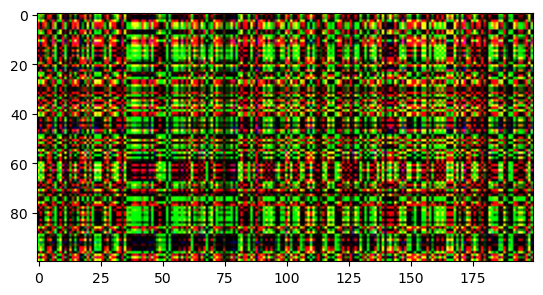

In [15]:
from mvt.tensor_view_transformer import TensorViewTransformer
import torch
import matplotlib.pyplot as plt
tensorformer = TensorViewTransformer(
    rank=20,
    out_dim=3,
    tensor_lengths=[100,200,10],
    depth=4,
    heads=8,
    dim_head=64,         
)

view = [torch.randn(1,20,100), 
    torch.randn(1,20,200), 
    torch.randn(1,20,10) ]
out = tensorformer(view)
print(out.shape)

plt.imshow(out[0].detach().numpy())
plt.show()


In [2]:
%timeit -r 10 tensorformer(view)

6.08 ms ± 106 µs per loop (mean ± std. dev. of 10 runs, 100 loops each)


## 1.2 Test on trained transformer 

In [1]:
import numpy as np
import gym
from env.habitat.exploration_env import load_config 
from model import RL_Policy
import torch 
from einops import rearrange
import matplotlib.pyplot as plt
from sklearn.decomposition import PCA
from sklearn.preprocessing import minmax_scale

/home/hongrui/miniconda3/envs/lena/lib/python3.9/site-packages/scipy/__init__.py:146: UserWarning: A NumPy version >=1.17.3 and <1.25.0 is required for this version of SciPy (detected version 1.26.4
  warnings.warn(f"A NumPy version >={np_minversion} and <{np_maxversion}"
PluginManager::Manager: duplicate static plugin StbImageImporter, ignoring
PluginManager::Manager: duplicate static plugin GltfImporter, ignoring
PluginManager::Manager: duplicate static plugin BasisImporter, ignoring
PluginManager::Manager: duplicate static plugin AssimpImporter, ignoring
PluginManager::Manager: duplicate static plugin AnySceneImporter, ignoring
PluginManager::Manager: duplicate static plugin AnyImageImporter, ignoring


### Load globaly policy 

In [2]:

nerf_map_cfg = load_config('env/habitat/configs/mapping.yaml')
bounding_box = np.array(nerf_map_cfg['mapping']['bound'])
diff = bounding_box[:,1] - bounding_box[:,0]
sdf_coarse = (diff / nerf_map_cfg['grid']['sdf_coarse']).astype(np.uint16)
rank = nerf_map_cfg['grid']['sdf_rank']
tensor_lengths = sdf_coarse.tolist()
total_length = sum(tensor_lengths)
g_observation_space = gym.spaces.Box(0, 1,
                                        (rank,
                                        total_length,
                                        1), dtype='float32') 

g_action_space = gym.spaces.Box(low=0.0, high=1.0,
                                    shape=(2,), dtype=np.float32)

tf_attn_dim = 128 
tf_out_dim = 16
tf_depth = 4 
tf_heads = 8
tf_dim_head = 64
g_hidden_size = 256 
use_recurrent_global = 0

In [3]:
g_policy = RL_Policy(g_observation_space.shape, g_action_space,
                        model_type='lena',
                        tensor_former_args={
                            'rank': nerf_map_cfg['grid']['sdf_rank'],
                            'tensor_lengths': sdf_coarse.tolist(),
                            'attn_dim': tf_attn_dim,
                            'out_dim': tf_out_dim,
                            'depth': tf_depth,
                            'heads': tf_heads,
                            'dim_head': tf_dim_head,
                        },
                        base_kwargs={'recurrent': use_recurrent_global,
                                    'hidden_size': g_hidden_size,
                                    })

In [19]:
load_global = 'results/models/train_aug11_fixDim/model_best.global'

In [20]:
state_dict = torch.load(load_global,
                        map_location=lambda storage, loc: storage)
g_policy.load_state_dict(state_dict)

transformer = g_policy.network.tensor_former


In [21]:
for name, para in transformer.named_parameters():
    print(name)
    print(para)

pos_embed
Parameter containing:
tensor([[[-1.1862,  0.1049, -0.9528,  ..., -0.7500, -1.6687, -1.7708],
         [ 1.7351,  0.3031, -0.7744,  ...,  0.4842, -0.4121, -2.1535],
         [-1.9216, -1.8024, -0.1650,  ..., -0.1137,  0.5126, -0.2267],
         ...,
         [ 1.0289, -1.0578,  2.7575,  ..., -1.4300,  3.0518, -0.1612],
         [-0.6111,  0.5695,  2.3662,  ..., -1.5424,  0.0718, -0.7586],
         [-0.7122, -0.3280, -0.0437,  ..., -1.6435,  0.5669,  1.1504]]],
       device='cuda:0', requires_grad=True)
input_projection.linear.weight
Parameter containing:
tensor([[ 0.0024, -0.0443, -0.0266,  ..., -0.1833, -0.0089, -0.0874],
        [-0.1293,  0.1208, -0.0411,  ...,  0.0302, -0.1510, -0.0941],
        [-0.0124, -0.1302,  0.0423,  ..., -0.0178,  0.0304, -0.0450],
        ...,
        [ 0.1568, -0.0947,  0.1382,  ...,  0.1413,  0.1066, -0.1575],
        [ 0.0294, -0.1589, -0.1376,  ..., -0.1084,  0.1712, -0.0558],
        [-0.1730, -0.0697,  0.1730,  ...,  0.1736, -0.0226,  0.026

### Load TensorRF

In [22]:
from mapping_test.model.scene_rep import JointEncoding

In [23]:
bounding_box = torch.from_numpy(np.array(nerf_map_cfg['mapping']['bound'])).to(torch.float32)
model = JointEncoding(nerf_map_cfg, bounding_box)

SDF resolution: 1000
Use blob


In [24]:
load_path = 'mapping_test/output/RL/aug_11_vis/agent_0/checkpoint_375.pt'
model.load_state_dict(torch.load(load_path)['model'])

<All keys matched successfully>

In [25]:
for name, para in model.named_parameters():
    print(name)

embedpos_fn.params
embed_fn.tensorxyz_coarse.0
embed_fn.tensorxyz_coarse.1
embed_fn.tensorxyz_coarse.2
embed_fn.tesnorxyz_fine.0
embed_fn.tesnorxyz_fine.1
embed_fn.tesnorxyz_fine.2
embed_fn.feature_tensor_coarse.weight
embed_fn.feature_tensor_fine.weight
decoder.color_net.model.0.weight
decoder.color_net.model.2.weight
decoder.sdf_net.model.0.weight
decoder.sdf_net.model.2.weight


### Pass TensorRF to Transformer 

In [48]:
device = torch.device('cuda:0')
transformer = transformer.to(device)
nerf_model = model.to(device)

tensor_list = nerf_model.embed_fn.tesnorxyz_fine

In [49]:
for item in tensor_list:
    print(item.shape)

torch.Size([1, 40, 3333, 1])
torch.Size([1, 40, 916, 1])
torch.Size([1, 40, 3333, 1])


In [28]:
out = transformer(tensor_list)
out_np = out[0].detach().cpu().numpy()
patch_h = out_np.shape[0]
patch_w = out_np.shape[1]
out_np = rearrange(out_np, 'h w c -> (h w) c')


In [29]:
pca = PCA(n_components=3)
pca_features = pca.fit_transform(out_np)
fg_result = minmax_scale(pca_features)
fg_result = rearrange(fg_result, ' (h w) c -> h w c', h=patch_h, w = patch_w)

In [30]:
plt.imshow(fg_result)
plt.savefig('test')

Just visualize raw tensors

In [ ]:
x_heat, y_heat, z_heat = tensor_list
x_heat = rearrange(x_heat.squeeze(-1), 'b r x -> b x r')
y_heat = rearrange(y_heat.squeeze(-1), 'b r y -> b y r')
z_heat = rearrange(z_heat.squeeze(-1), 'b r z -> b z r')

y_mean = torch.mean(y_heat, dim=1)
out_np = torch.einsum('bxr, bzr, br -> bxzr', x_heat, z_heat, y_mean)
out_np = out[0].detach().cpu().numpy()
out_np = rearrange(out_np, 'h w c -> (h w) c')

pca = PCA(n_components=3)
pca_features = pca.fit_transform(out_np)
fg_result = minmax_scale(pca_features)
fg_result = rearrange(fg_result, ' (h w) c -> h w c', h=patch_h, w = patch_w)

plt.imshow(fg_result)
plt.savefig('raw_vis')
